In [1]:
from pathlib import Path
import os 
from dataclasses import dataclass
import yaml
import copy

from tqdm.notebook import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import seaborn as sns

from torch.nn.utils import parameters_to_vector 
#import torch.nn.utils.prune as prune

import sys
sys.path.append('../../')
sys.path.append('../')

from src import prune 
from src import mod_cog_tasks as mct 
from src import mod_cog_data_utils as mcdu
from src import eg_utils
from src import analysis_utils as au
from src import plot_utils as pu
from src import initializations

from train_mod_cog import RNNModel

device = eg_utils.get_device()

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


['/home/mila/p/pingsheng.li/projects/eg_rnns/mod_cog/analysis/arial.ttf']
/home/mila/p/pingsheng.li/projects/eg_rnns/mod_cog/analysis/arial.ttf
/home/mila/p/pingsheng.li/projects/eg_rnns/mod_cog/analysis/arial.ttf


In [2]:
%load_ext autoreload
%autoreload 2

# Defining folders with experiments

In [3]:
results_dir = Path(os.path.join(os.environ['SCRATCH'], "eg_paper/mod_cog/exp8_final_combined_with_cgd"))
os.listdir(results_dir)

['eg_N2500_lr3.5_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-06_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-06_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr0.1_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr0.1_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr1.0_m0.925_wd1e-06_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr1.0_m0.925_wd1e-06_mxgn2.0_init_uniform_a1.0_l

In [4]:
def format_exp_as_key(exp_name):
    if exp_name.startswith("eg_unsigned"):
        s = "eg_unsigned"
    elif exp_name.startswith("cgd"):
        s = "cgd"
    else:
        s = exp_name[:2]
    if "log_normal" in exp_name:
        s += "_log_normal"
    elif "normal" in exp_name:
        s += "_normal"
    elif "uniform" in exp_name:
        s += "_uniform"
    return s


# comparing 1e-7 eg, 1e-6 gd
exp_names = []
for exp_name in os.listdir(results_dir):
    if exp_name.startswith("eg"):
        if "1e-07" in exp_name:exp_names.append(exp_name)
    elif exp_name.startswith("gd"):
        if "1e-06" in exp_name:exp_names.append(exp_name)
    elif exp_name.startswith("cgd"):
        if "1e-06" in exp_name:exp_names.append(exp_name)
print(exp_names)

# reformat exp_name for use as a key
exp_folders = au.DotDict({format_exp_as_key(f):results_dir/f for f in exp_names})
results_dict = au.load_results(exp_folders)

['eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss', 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss', 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss', 'eg_unsigned_N2500_lr0.1_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss', 'eg_unsigned_N2500_lr0.1_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss', 'eg_unsigned_N2500_lr1.0_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss', 'eg_unsigned_N2500_lr1.0_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss', 'eg_unsigned_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss', 'eg_unsigned_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss', 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss', 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_normal_a1.0_lrsched_custom_loss', 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_uniform_a1.0_lrsched_cust

In [5]:
results_dict.keys()

dict_keys(['eg_log_normal', 'eg_normal', 'eg_uniform', 'eg_unsigned_normal', 'eg_unsigned_uniform', 'gd_log_normal', 'gd_normal', 'gd_uniform', 'cgd_log_normal', 'eg_unsigned_log_normal'])

In [6]:
# Add colours to exps
# https://www.datylon.com/blog/data-visualization-for-colorblind-readers
results_dict.eg_normal.c = "#fec615" # golden yellow
results_dict.eg_uniform.c = "green" #ff9408" # tangerine
results_dict.eg_log_normal.c = "#f05039" # orangey red

results_dict.gd_log_normal.c = "#1f449c" # blue
results_dict.gd_normal.c = "#8af1fe"
results_dict.gd_uniform.c = "#9e43a2"

results_dict.cgd_log_normal.c = "#2ca02c" # green

In [7]:
def get_model(cfg):
    input_size = 115 # hardcoded for now, but should make responsive to data
    output_size = 17
    model = RNNModel(input_size, cfg.model.hidden_size, output_size)
    if cfg.update_alg == "eg":
        eg_utils.set_split_bias(model)
        print("Setting split bias")
    return model

def load_ckpt(model, ckpt_path):
    device = eg_utils.get_device()
    state_dict = torch.load(ckpt_path,map_location=device)
    model.load_state_dict(state_dict)
    return model

In [8]:
def get_non_bias_params(model):
    """returns a list of parameters that are not biases"""
    non_bias_params = []
    for n, p in model.named_parameters():
        if "bias" in n: continue
        else : non_bias_params.append(p)
        #print(f"appended {n}, {p.shape} to params")
    return non_bias_params

def calc_cosine_similarity(vec1, vec2):
    with torch.no_grad():
        return vec1@vec2 / (vec1.norm() * vec2.norm())
    
def get_non_bias_pruneparams(model, verbose=False):
    """
    Note torch.nn.utils.prune expects iterables of (module, parameter_name) pairs 
    """
    parameters = []
    for mod_name, mod in model.named_modules():
        #print(mod_name)
        for n, p in mod.named_parameters(recurse=False):
            #print(n)
            if "bias" in n: continue
            else : 
                parameters.append((mod, n))
                if verbose: print(f"appended {mod_name}:{n}, {p.shape} to params")

    return parameters

def prune_and_clean_prune_param(module_pnames_iterable, amount):
    prune.global_unstructured(module_pnames_iterable, pruning_method=prune.L1Unstructured, amount=amount)
    for mod, pname in module_pnames_iterable:
        prune.remove(mod, pname)

In [9]:
def get_cos_similarities(model, base_model, prune_props, ckpt=None):
    if sorted(prune_props) != prune_props:
        raise ValueError("prune_props must be sorted")
    
    if ckpt is not None:
        model = load_ckpt(model, ckpt)
        base_model = load_ckpt(base_model, ckpt)
        
    cos_sims = []
    base_params = parameters_to_vector(get_non_bias_params(base_model)).detach()
    for prop in prune_props:
        to_prune = get_non_bias_pruneparams(model)
        prune_and_clean_prune_param(to_prune, prop)
        model_params = parameters_to_vector(get_non_bias_params(model)).detach()
        cos_sim = calc_cosine_similarity(base_params, model_params)
        cos_sims.append(cos_sim)
    return cos_sims

In [10]:
# Grab checkpoints
gd_log_normal_init = results_dict.gd_log_normal.seed_7.epoch_ckpts[0]
gd_uniform_init = results_dict.gd_uniform.seed_7.epoch_ckpts[0]
gd_normal_init = results_dict.gd_normal.seed_7.epoch_ckpts[0]

cgd_log_normal_init = results_dict.cgd_log_normal.seed_7.epoch_ckpts[0]

idx = -2
gd_log_normal_final_ckpt = results_dict.gd_log_normal.seed_7.epoch_ckpts[idx]
gd_uniform_final_ckpt = results_dict.gd_uniform.seed_7.epoch_ckpts[idx]
gd_normal_final_ckpt = results_dict.gd_normal.seed_7.epoch_ckpts[idx]

cgd_log_normal_final_ckpt = results_dict.cgd_log_normal.seed_7.epoch_ckpts[idx]

eg_log_normal_final_ckpt = results_dict.eg_log_normal.seed_7.epoch_ckpts[idx]
eg_uniform_final_ckpt = results_dict.eg_uniform.seed_7.epoch_ckpts[idx]
eg_normal_final_ckpt = results_dict.eg_normal.seed_7.epoch_ckpts[idx]

# Create models
gd_exp = results_dict.gd_log_normal.seed_7
eg_exp = results_dict.eg_log_normal.seed_7
cgd_exp = results_dict.cgd_log_normal.seed_7
gd_model = get_model(gd_exp.cfg)
eg_model = get_model(eg_exp.cfg)
cgd_model = get_model(cgd_exp.cfg)

gd_model_base = get_model(gd_exp.cfg)
eg_model_base = get_model(eg_exp.cfg)
cgd_model_base = get_model(cgd_exp.cfg)

# gd_model = load_ckpt(gd_model, gd_exp.epoch_ckpts[-1])
# eg_model = load_ckpt(eg_model, eg_exp.epoch_ckpts[-1])
# gd_model_base = load_ckpt(gd_model_base, gd_exp.epoch_ckpts[-1])
# eg_model_base = load_ckpt(eg_model_base, eg_exp.epoch_ckpts[-1])

Setting split bias
Setting split bias


In [11]:
prune_props = np.concatenate([np.linspace(0,0.9,10), np.linspace(0.9,0.99,10), np.linspace(0.99,0.999,10)])
prune_props = sorted(1-np.logspace(-5,0,20))

eg_cos_sims_ln = {}
idx = -2
for seed_key in results_dict.eg_log_normal.keys():
    if not seed_key.startswith("seed"): continue
    print(seed_key, end=",")
    ckpt = results_dict.eg_log_normal[seed_key].epoch_ckpts[idx]
    eg_cos_sims_ln[seed_key] = get_cos_similarities(eg_model, eg_model_base, prune_props, ckpt)

seed_5,

/tmp/ipykernel_2528372/171395204.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_path,map_location=device)


seed_6,seed_7,seed_8,seed_9,

In [12]:
gd_cos_sims_ln = {}
idx = -2
for seed_key in results_dict.gd_log_normal.keys():
    if not seed_key.startswith("seed"): continue
    print(seed_key, end=",")
    ckpt = results_dict.gd_log_normal[seed_key].epoch_ckpts[idx]
    gd_cos_sims_ln[seed_key] = get_cos_similarities(gd_model, gd_model_base, prune_props, ckpt)

seed_5,

/tmp/ipykernel_2528372/171395204.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_path,map_location=device)


seed_6,seed_7,seed_8,seed_9,

In [13]:
cgd_cos_sims_ln = {}
idx = -2
for seed_key in results_dict.cgd_log_normal.keys():
    if not seed_key.startswith("seed"): continue
    print(seed_key, end=",")
    ckpt = results_dict.cgd_log_normal[seed_key].epoch_ckpts[idx]
    cgd_cos_sims_ln[seed_key] = get_cos_similarities(cgd_model, cgd_model_base, prune_props, ckpt)

seed_5,

/tmp/ipykernel_2528372/171395204.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_path,map_location=device)


seed_6,seed_7,seed_8,seed_9,

In [14]:
# stack into array

gd_arr = np.array(list(gd_cos_sims_ln.values())).T
eg_arr = np.array(list(eg_cos_sims_ln.values())).T
cgd_arr = np.array(list(cgd_cos_sims_ln.values())).T



In [29]:
eg_arr.mean(axis=1).shape

(20,)

In [30]:
eg_arr.std(axis=1)

array([2.9756702e-05, 7.5917307e-04, 2.3670911e-03, 4.3715769e-03,
       6.5103173e-03, 8.6133452e-03, 1.0572140e-02, 1.2354962e-02,
       1.3933853e-02, 1.5308580e-02, 1.6471798e-02, 1.7482737e-02,
       1.8464811e-02, 1.9491510e-02, 2.0694338e-02, 2.2421727e-02,
       2.4107035e-02, 2.5093026e-02, 2.7844138e-02, 3.1328145e-02],
      dtype=float32)

/tmp/ipykernel_2528372/1975643844.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


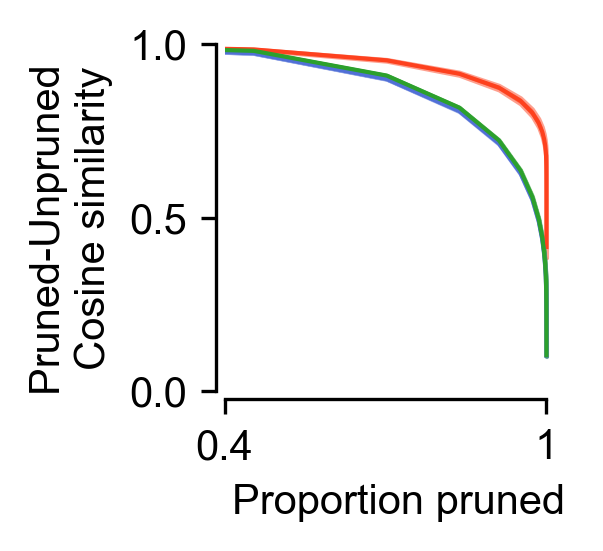

In [15]:
plt.figure(figsize=(1.5,1.5), dpi = 300)
gd_c="#5170d7"
eg_c="#fd411e"
cgd_c="#2ca02c"

# plt.plot(prune_props, gd_cos_sims_ln,  color=gd_c)
# plt.plot(prune_props, eg_cos_sims_ln,  color=eg_c)

plt.fill_between(prune_props, 
                 eg_arr.mean(axis=1)-eg_arr.std(axis=1), eg_arr.mean(axis=1)+eg_arr.std(axis=1),
                 color=eg_c, alpha=0.5)

plt.plot(prune_props, eg_arr.mean(axis=1), color=eg_c, alpha=1, lw=1)

plt.fill_between(prune_props, 
                 gd_arr.mean(axis=1)-gd_arr.std(axis=1), gd_arr.mean(axis=1)+gd_arr.std(axis=1),
                 color=gd_c, alpha=0.5)

plt.plot(prune_props, gd_arr.mean(axis=1), color=gd_c, alpha=1, lw=1)

plt.fill_between(prune_props, 
                 cgd_arr.mean(axis=1)-cgd_arr.std(axis=1), cgd_arr.mean(axis=1)+cgd_arr.std(axis=1),
                 color=cgd_c, alpha=0.5)    

plt.plot(prune_props, cgd_arr.mean(axis=1), color=cgd_c, alpha=1, lw=1)


# plt.plot(prune_props, log_normal_sims, label="Log Normal", color="red", linestyle="--", alpha=0.5)
# plt.plot(prune_props, uniform_sims, label="Uniform", color="blue", linestyle="--", alpha=0.5)
# plt.plot(prune_props, normal_sims, label="Normal", color="grey", linestyle="--", alpha=0.5)

# plt.plot(prune_props, cos_sims, label=f"mean_std_ratio={ratio:.2f}", linestyle="--", alpha=0.5) 
# plt.plot(prune_props, eg_arr, color=eg_c, alpha=1, lw=1)
# plt.plot(prune_props, gd_arr, color=gd_c, alpha=1, lw=1)
# plt.plot(prune_props, cgd_arr, color=cgd_c, alpha=1, lw=1)

plt.legend(frameon=False)
plt.ylim(0., 1)
plt.yticks([0, 0.5, 1])
plt.xlim(0.4,1.05)
#plt.xticks([0.4, max(prune_props)], labels=["0.4", str(max(prune_props))])
plt.xticks([0.4, 1], labels=["0.4", "1"])


plt.ylabel("Pruned-Unpruned  \nCosine similarity")
plt.xlabel("Proportion pruned")
#plt.title("EG vs GD with reference dists")
# plt.savefig("figs/fig2/2cos_sim.png", transparent=True, bbox_inches="tight")

sns.despine(offset=2, trim=True)

# plt.savefig("figs/fig2/2b_cos_sim_ln.pdf", transparent=True, bbox_inches="tight")

# save the data used to plot the figure
data_dict = {
    "prune_props": prune_props,
    "eg_cos_sims_ln": eg_arr,
    "gd_cos_sims_ln": gd_arr,
    "cgd_cos_sims_ln": cgd_arr
}
np.savez("plot_data/Fig2a_cSGD_cos_sims_ln.npz", **data_dict)



## 

# What is the 0 shot drop in performance when pruning

In [16]:
@dataclass
class DataConfig:
    batch_size: int = 512
    seq_len:int = 350
    copy_data_to_device_mem: bool = False
    num_workers: int = 0
    pin_memory: bool = True

cfg = DataConfig()

# load data
# change to linclab path
# data_dir = Path("/network/scratch/c/cornforj/eg_paper/mod_cog_data_v2")
data_dir = Path("/network/projects/_groups/linclab_users/eg/modcog/data_v2")
print(os.listdir(data_dir)[:])

loaders = {}
for split in ["train", "val", "test"]:
    dataset = mcdu.ModCogDataset(data_dir, split=split, in_memory=cfg.copy_data_to_device_mem)
    loaders[split] = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=split=="train",
                                num_workers=cfg.num_workers, pin_memory=cfg.pin_memory)

['mod_cog_test.npz', 'mod_cog_test_x.memmap', 'mod_cog_test_y.memmap', 'mod_cog_train.npz', 'mod_cog_train_x.memmap', 'mod_cog_train_y.memmap', 'mod_cog_val.npz', 'mod_cog_val_x.memmap', 'mod_cog_val_y.memmap', 'slurm-4893722.out']
Loading train memmap files /network/projects/_groups/linclab_users/eg/modcog/data_v2
Loading val memmap files /network/projects/_groups/linclab_users/eg/modcog/data_v2
Loading test memmap files /network/projects/_groups/linclab_users/eg/modcog/data_v2


In [17]:
from train_mod_cog import ModCogLossMSE, ModCogLossCombined, compute_acc_with_fixation_unit

@torch.no_grad()
def evaluate_model(model, loaders, custom_loss=True, mse_only_custom_loss=False, epoch_idx=None, debug=False):
    """This is only used when using cached data."""
    if epoch_idx is None: epoch_idx = 0
    results_dict = {}
    device = eg_utils.get_device()
    model.eval()

    if mse_only_custom_loss:
        full_loss = ModCogLossMSE()
    else:
        full_loss = ModCogLossCombined(label_smoothing=0.1)

    ce_criterion = torch.nn.CrossEntropyLoss()

    for split in ["val"]:
        loader = loaders[split]
        accs = []
        dec_accs = []
        losses = []
        for i, (inputs, labels) in enumerate(loader):
            inputs = inputs.to(device)
            task_rules = inputs[:,:,-1]
            one_hot_rule_inputs = torch.nn.functional.one_hot(task_rules.long(), num_classes=82).float()
            inputs = torch.cat([inputs[:,:,:-1], one_hot_rule_inputs], dim=-1)
            inputs = inputs.to(device)
            labels = labels.to(device).long()

            outputs = model(inputs)
            dec_mask = inputs[:, :, 0] == 0

            acc, dec_acc = compute_acc_with_fixation_unit(outputs, labels, dec_mask)

            if custom_loss:
                loss = full_loss(outputs, labels, dec_mask)[0]  # [0] ignores individial .item()-ized losses
            else:
                loss = ce_criterion(input=outputs.permute(0,2,1), target=labels)
            accs.append(acc)
            dec_accs.append(dec_acc)
            losses.append(loss.item())
            #print(i)
            if debug and i > 20: break
        mean_acc = np.mean(accs)
        mean_dec_acc = np.mean(dec_accs)
        mean_loss = np.mean(losses)
        print(f"{epoch_idx}:{split} Acc: {mean_acc:.2f}, Dec Acc: {mean_dec_acc:.2f}, Loss: {mean_loss:.2f}")
        results_dict[f"{split}_Acc"] = mean_acc
        results_dict[f"{split}_Dec_Acc"] = mean_dec_acc
        results_dict[f"{split}_Loss"] = mean_loss

    return results_dict



In [18]:
eg_model = load_ckpt(eg_model, eg_log_normal_final_ckpt)
eg_model.to(device)
evaluate_model(model=eg_model, loaders=loaders, debug=True)

/tmp/ipykernel_2528372/171395204.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_path,map_location=device)


0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.62


{'val_Acc': np.float64(0.9936368627981707),
 'val_Dec_Acc': np.float64(0.9809202064167369),
 'val_Loss': np.float64(0.6212203773585233)}

In [19]:
prune_props = list(np.concatenate([np.linspace(0,0.8,10),np.linspace(0.825,0.99,5)])) + [0.99999]
prune_props 


[np.float64(0.0),
 np.float64(0.08888888888888889),
 np.float64(0.17777777777777778),
 np.float64(0.26666666666666666),
 np.float64(0.35555555555555557),
 np.float64(0.4444444444444445),
 np.float64(0.5333333333333333),
 np.float64(0.6222222222222222),
 np.float64(0.7111111111111111),
 np.float64(0.8),
 np.float64(0.825),
 np.float64(0.86625),
 np.float64(0.9075),
 np.float64(0.94875),
 np.float64(0.99),
 0.99999]

In [20]:
eg = []
idx = -2
for seed_key in results_dict.eg_log_normal.keys():
    if not seed_key.startswith("seed"): continue
    print(seed_key)
    ckpt = results_dict.eg_log_normal[seed_key].epoch_ckpts[idx]
    eg_model = load_ckpt(eg_model, ckpt)
    model = eg_model.to(device)
    
    prune_results_dict_eg = {}
    for prop in prune_props:
        print(f"\t {prop:.5f}", end=", ")
        to_prune = get_non_bias_pruneparams(model)
        prune_and_clean_prune_param(to_prune, prop)
        eval_dict = evaluate_model(model=model, loaders=loaders, debug=True)
        prune_results_dict_eg = au.concat_dict(prune_results_dict_eg, eval_dict)
    eg.append(prune_results_dict_eg)

seed_5
	 0.00000, 

/tmp/ipykernel_2528372/171395204.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_path,map_location=device)


0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.62
	 0.08889, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.62
	 0.17778, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.63
	 0.26667, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.64
	 0.35556, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.64
	 0.44444, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.64
	 0.53333, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.65
	 0.62222, 0:val Acc: 0.99, Dec Acc: 0.97, Loss: 0.68
	 0.71111, 0:val Acc: 0.97, Dec Acc: 0.91, Loss: 0.84
	 0.80000, 0:val Acc: 0.92, Dec Acc: 0.76, Loss: 1.35
	 0.82500, 0:val Acc: 0.90, Dec Acc: 0.69, Loss: 1.55
	 0.86625, 0:val Acc: 0.86, Dec Acc: 0.56, Loss: 1.90
	 0.90750, 0:val Acc: 0.81, Dec Acc: 0.42, Loss: 2.24
	 0.94875, 0:val Acc: 0.77, Dec Acc: 0.30, Loss: 2.54
	 0.99000, 0:val Acc: 0.73, Dec Acc: 0.17, Loss: 2.84
	 0.99999, 0:val Acc: 0.02, Dec Acc: 0.06, Loss: 3.42
seed_6
	 0.00000, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.62
	 0.08889, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.63
	 0.17778, 0:val Acc: 0.99, Dec 

In [21]:
gd = []
idx = -2
for seed_key in results_dict.gd_log_normal.keys():
    if not seed_key.startswith("seed"): continue
    print(seed_key)
    ckpt = results_dict.gd_log_normal[seed_key].epoch_ckpts[idx]
    gd_model = load_ckpt(gd_model, ckpt)
    model = gd_model.to(device)
    
    prune_results_dict_gd = {}
    for prop in prune_props:
        print(f"\t {prop:.5f}", end=", ")
        to_prune = get_non_bias_pruneparams(model)
        prune_and_clean_prune_param(to_prune, prop)
        eval_dict = evaluate_model(model=model, loaders=loaders, debug=True)
        prune_results_dict_gd = au.concat_dict(prune_results_dict_gd, eval_dict)
    gd.append(prune_results_dict_gd)

seed_5
	 0.00000, 

/tmp/ipykernel_2528372/171395204.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_path,map_location=device)


0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.63
	 0.08889, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.63
	 0.17778, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.63
	 0.26667, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.63
	 0.35556, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.63
	 0.44444, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.65
	 0.53333, 0:val Acc: 0.99, Dec Acc: 0.96, Loss: 0.71
	 0.62222, 0:val Acc: 0.97, Dec Acc: 0.90, Loss: 0.93
	 0.71111, 0:val Acc: 0.91, Dec Acc: 0.72, Loss: 1.52
	 0.80000, 0:val Acc: 0.83, Dec Acc: 0.48, Loss: 2.08
	 0.82500, 0:val Acc: 0.81, Dec Acc: 0.41, Loss: 2.22
	 0.86625, 0:val Acc: 0.77, Dec Acc: 0.30, Loss: 2.45
	 0.90750, 0:val Acc: 0.75, Dec Acc: 0.22, Loss: 2.60
	 0.94875, 0:val Acc: 0.72, Dec Acc: 0.15, Loss: 2.72
	 0.99000, 0:val Acc: 0.70, Dec Acc: 0.08, Loss: 2.79
	 0.99999, 0:val Acc: 0.68, Dec Acc: 0.00, Loss: 3.00
seed_6
	 0.00000, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.63
	 0.08889, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.63
	 0.17778, 0:val Acc: 0.99, Dec 

In [22]:
cgd = []
idx = -2
for seed_key in results_dict.cgd_log_normal.keys():
    if not seed_key.startswith("seed"): continue
    print(seed_key)
    ckpt = results_dict.cgd_log_normal[seed_key].epoch_ckpts[idx]
    cgd_model = load_ckpt(cgd_model, ckpt)
    model = cgd_model.to(device)
    
    prune_results_dict_cgd = {}
    for prop in prune_props:
        print(f"\t {prop:.5f}", end=", ")
        to_prune = get_non_bias_pruneparams(model)
        prune_and_clean_prune_param(to_prune, prop)
        eval_dict = evaluate_model(model=model, loaders=loaders, debug=True)
        prune_results_dict_cgd = au.concat_dict(prune_results_dict_cgd, eval_dict)
    cgd.append(prune_results_dict_cgd)

seed_5
	 0.00000, 

/tmp/ipykernel_2528372/171395204.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_path,map_location=device)


0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.63
	 0.08889, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.63
	 0.17778, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.63
	 0.26667, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.63
	 0.35556, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.64
	 0.44444, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.64
	 0.53333, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.64
	 0.62222, 0:val Acc: 0.99, Dec Acc: 0.97, Loss: 0.68
	 0.71111, 0:val Acc: 0.97, Dec Acc: 0.91, Loss: 0.93
	 0.80000, 0:val Acc: 0.88, Dec Acc: 0.64, Loss: 1.72
	 0.82500, 0:val Acc: 0.85, Dec Acc: 0.54, Loss: 1.95
	 0.86625, 0:val Acc: 0.80, Dec Acc: 0.39, Loss: 2.27
	 0.90750, 0:val Acc: 0.76, Dec Acc: 0.25, Loss: 2.53
	 0.94875, 0:val Acc: 0.73, Dec Acc: 0.17, Loss: 2.68
	 0.99000, 0:val Acc: 0.73, Dec Acc: 0.18, Loss: 2.77
	 0.99999, 0:val Acc: 0.06, Dec Acc: 0.17, Loss: 2.92
seed_6
	 0.00000, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.63
	 0.08889, 0:val Acc: 0.99, Dec Acc: 0.98, Loss: 0.63
	 0.17778, 0:val Acc: 0.99, Dec 

In [ ]:
# stack these things

In [23]:
gd_arr = np.vstack([d["val_Dec_Acc"] for d in gd]).T
eg_arr = np.vstack([d["val_Dec_Acc"] for d in eg]).T
cgd_arr = np.vstack([d["val_Dec_Acc"] for d in cgd]).T

/tmp/ipykernel_2528372/284799765.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


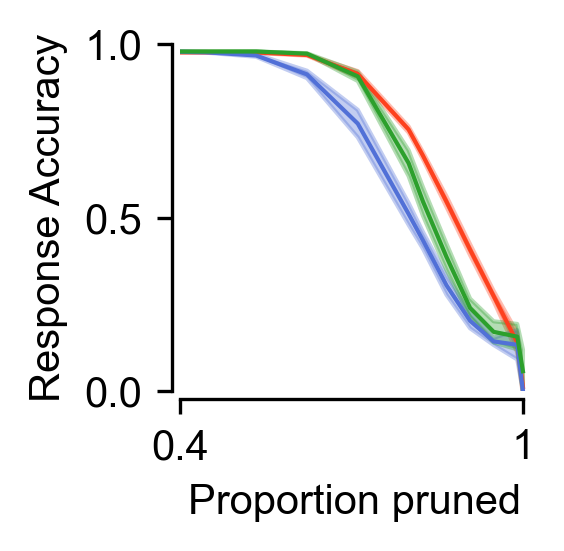

In [25]:
plt.figure(figsize=(1.5,1.5), dpi = 300)
gd_c="#5170d7"
eg_c="#fd411e"
cgd_c="#2ca02c"

# plt.plot(prune_props, gd_arr.mean(axis=0), color=gd_c)
# plt.plot(prune_props, eg_arr.T, color=eg_c)

plt.fill_between(prune_props, 
                 eg_arr.mean(axis=1)-eg_arr.std(axis=1), eg_arr.mean(axis=1)+eg_arr.std(axis=1),
                 color=eg_c, alpha=0.35)

plt.plot(prune_props, eg_arr.mean(axis=1), color=eg_c, alpha=1, lw=1)

plt.fill_between(prune_props, 
                 gd_arr.mean(axis=1)-gd_arr.std(axis=1), gd_arr.mean(axis=1)+gd_arr.std(axis=1),
                 color=gd_c, alpha=0.35)

plt.plot(prune_props, gd_arr.mean(axis=1), color=gd_c, alpha=1, lw=1)

plt.fill_between(prune_props, 
                 cgd_arr.mean(axis=1)-cgd_arr.std(axis=1), cgd_arr.mean(axis=1)+cgd_arr.std(axis=1),
                 color=cgd_c, alpha=0.35)       

plt.plot(prune_props, cgd_arr.mean(axis=1), color=cgd_c, alpha=1, lw=1)


plt.legend(frameon=False)
plt.ylim(0., 1)
plt.yticks([0, 0.5, 1])
plt.xlim(0.4,1.01)
plt.xticks([0.4, 1], labels=["0.4", "1"])

plt.xlabel("Proportion pruned")
plt.ylabel("Response Accuracy")

sns.despine(offset=2, trim=True)
# plt.savefig("figs/fig2/2c_dec_acc.pdf", transparent=True, bbox_inches="tight")
# save the data used to plot the figure
data_dict = {
    "prune_props": prune_props,
    "eg_dec_acc": eg_arr,
    "gd_dec_acc": gd_arr,
    "cgd_dec_acc": cgd_arr
}
np.savez("plot_data/Fig2a_cSGD_dec_acc.npz", **data_dict)